In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

print(nav.head())
print(nav.info())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB
None


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


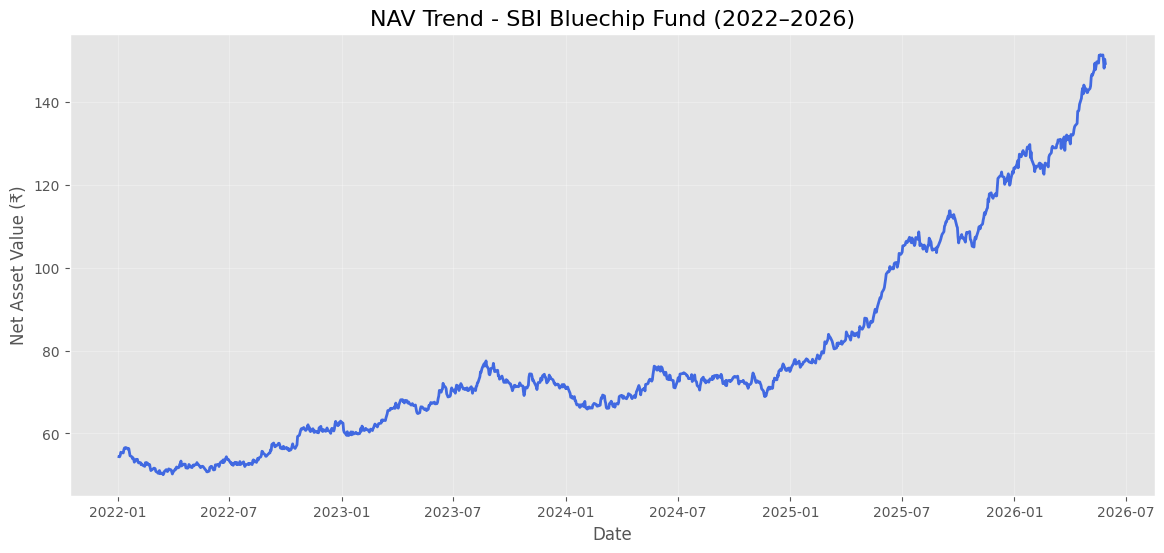

In [5]:
plt.figure(figsize=(14,6))

plt.plot(fund["date"], fund["nav"],
         color="royalblue",
         linewidth=2)

plt.title("NAV Trend - SBI Bluechip Fund (2022–2026)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Net Asset Value (₹)")

plt.grid(alpha=0.3)

plt.show()

In [6]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.show()

In [7]:
import plotly.express as px


In [8]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_all = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [9]:
fig = px.line(
    nav_all,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (₹)",
        "scheme_name": "Scheme"
    }
)

fig.update_layout(
    width=1200,
    height=650,
    template="plotly_white"
)

fig.show()

In [10]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [11]:
print(aum.head())
print(aum.info())

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB
None


In [12]:
aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


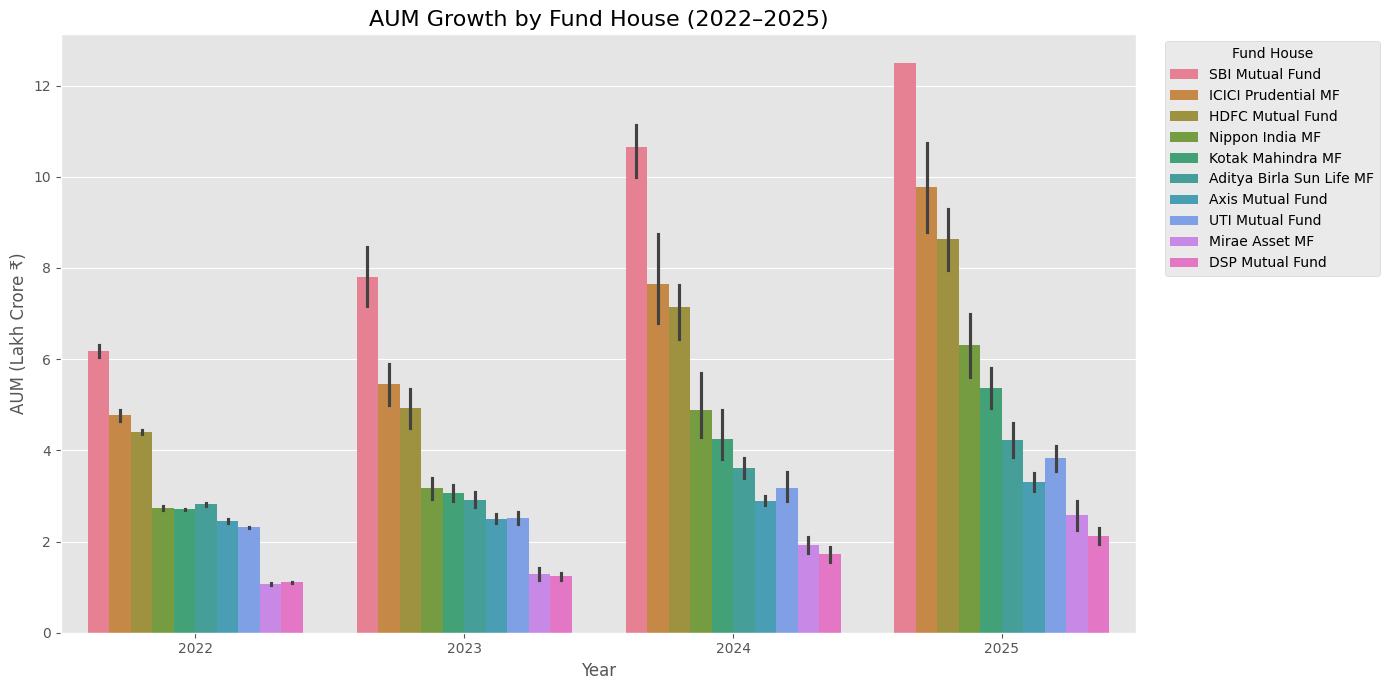

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.legend(title="Fund House", bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

In [14]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.info())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   month                      48 non-null     objec

In [15]:
sip["month"] = pd.to_datetime(sip["month"])

In [16]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white"
)

fig.show()

In [17]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Highest: ₹{max_row['sip_inflow_crore']} Cr",
    showarrow=True,
    arrowhead=2
)

fig.show()

In [18]:
## Business Insights

• Monthly SIP inflows show a consistent upward trend over the years.

• The highest monthly SIP inflow reached ₹31,002 crore (if reflected in the dataset), indicating growing investor confidence in mutual funds.

• The increasing trend suggests higher retail participation and long-term investment discipline.

• Temporary fluctuations may reflect market volatility or seasonal investment behavior.

SyntaxError: invalid character '•' (U+2022) (3665021187.py, line 3)

In [19]:
print(sip["sip_inflow_crore"].max())

31002


In [20]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())
print(category.info())

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB
None


In [21]:
category["month"] = pd.to_datetime(category["month"])

category["month"] = category["month"].dt.strftime("%b-%Y")

In [22]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

pivot.head()

month,Apr-2024,Aug-2024,Dec-2024,Feb-2025,Jan-2025,Jul-2024,Jun-2024,Mar-2025,May-2024,Nov-2024,Oct-2024,Sep-2024
category,,,,,,,,,,,,
ELSS,466.0,499.0,521.0,437.0,516.0,471.0,472.0,500.0,553.0,571.0,537.0,537.0
Flexi Cap,4947.0,5562.0,4654.0,6068.0,5603.0,4869.0,4478.0,4767.0,5529.0,6111.0,6004.0,5397.0
Gilt,784.0,952.0,831.0,942.0,744.0,959.0,864.0,956.0,836.0,704.0,898.0,925.0
Hybrid,2955.0,3684.0,3538.0,3360.0,2967.0,3291.0,3163.0,2830.0,3487.0,3264.0,3314.0,3015.0
Large & Mid Cap,4214.0,5411.0,4878.0,5524.0,4816.0,5023.0,4610.0,4243.0,4368.0,5556.0,4581.0,4528.0


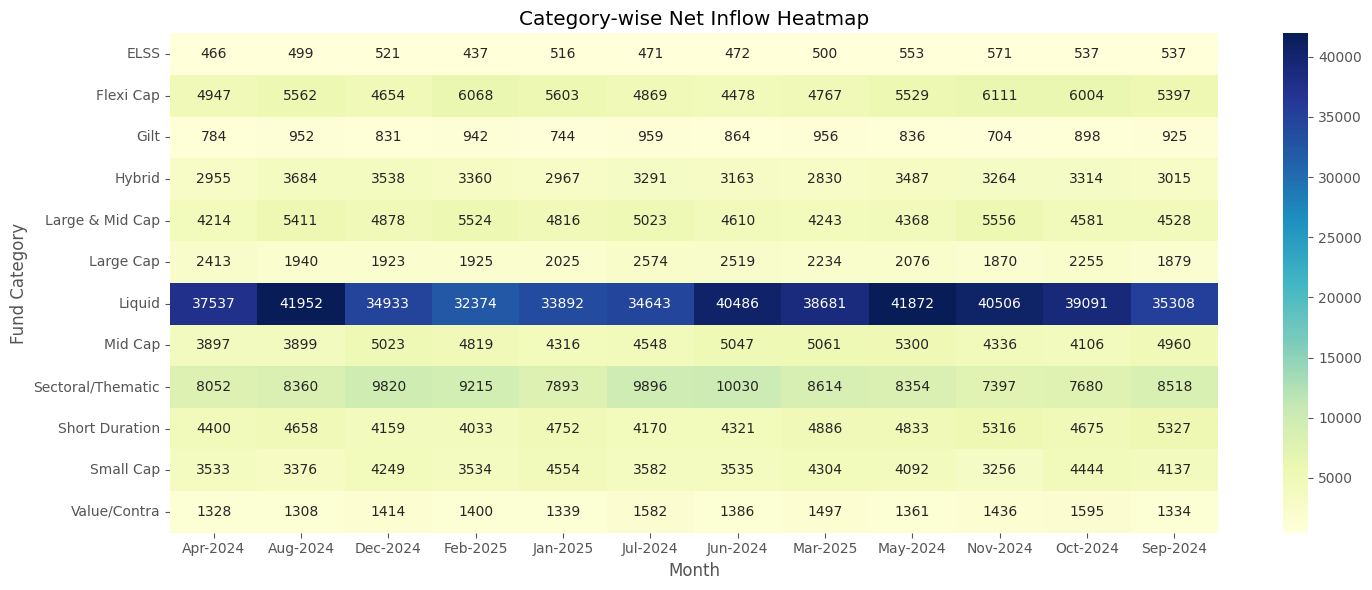

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [24]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(investor.head())
print(investor.info())

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [25]:
age_counts = investor["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

In [26]:
import plotly.express as px

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Distribution by Age Group"
)

fig.show()

In [27]:
gender = investor["gender"].value_counts()

fig = px.bar(
    x=gender.index,
    y=gender.values,
    color=gender.index,
    title="Gender Distribution of Investors"
)

fig.update_layout(
    xaxis_title="Gender",
    yaxis_title="Number of Investors"
)

fig.show()

In [28]:
city = investor["city_tier"].value_counts()

fig = px.pie(
    values=city.values,
    names=city.index,
    title="Investor Distribution by City Tier"
)

fig.show()

In [29]:
payment = investor["payment_mode"].value_counts()

fig = px.bar(
    x=payment.index,
    y=payment.values,
    color=payment.index,
    title="Preferred Payment Mode"
)

fig.show()

In [30]:
import pandas as pd
import plotly.express as px

investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [31]:
investor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [32]:
fig = px.pie(
    values=age.values,
    names=age.index,
    title="Investor Distribution by Age Group",
    hole=0.4
)

fig.show()

NameError: name 'age' is not defined

In [33]:
age = investor["age_group"].value_counts()

print(age)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


In [34]:
import plotly.express as px

fig = px.pie(
    values=age.values,
    names=age.index,
    title="Investor Distribution by Age Group",
    hole=0.4
)

fig.show()

In [35]:
gender = investor["gender"].value_counts()

gender

gender
Male      21809
Female    10969
Name: count, dtype: int64

In [36]:
import plotly.express as px

fig = px.bar(
    x=gender.index,
    y=gender.values,
    color=gender.index,
    text=gender.values,
    title="Gender Distribution of Investors"
)

fig.update_layout(
    xaxis_title="Gender",
    yaxis_title="Number of Investors"
)

fig.show()

In [37]:
city_tier = investor["city_tier"].value_counts()

city_tier

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

In [38]:
fig = px.pie(
    values=city_tier.values,
    names=city_tier.index,
    title="Investor Distribution by City Tier",
    hole=0.4
)

fig.show()

In [39]:
payment = investor["payment_mode"].value_counts()

payment

payment_mode
Net Banking    8250
Cheque         8228
UPI            8154
Mandate        8146
Name: count, dtype: int64

In [40]:
import plotly.express as px

fig = px.bar(
    x=payment.index,
    y=payment.values,
    color=payment.index,
    text=payment.values,
    title="Preferred Payment Modes"
)

fig.update_layout(
    xaxis_title="Payment Mode",
    yaxis_title="Number of Transactions"
)

fig.show()

In [41]:
kyc = investor["kyc_status"].value_counts()

kyc

kyc_status
Verified    30146
Pending      2632
Name: count, dtype: int64

In [42]:
import plotly.express as px

fig = px.pie(
    values=kyc.values,
    names=kyc.index,
    title="KYC Status of Investors",
    hole=0.4
)

fig.show()

In [43]:
transaction = investor["transaction_type"].value_counts()

transaction

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [44]:
fig = px.bar(
    x=transaction.index,
    y=transaction.values,
    color=transaction.index,
    text=transaction.values,
    title="Transaction Type Distribution"
)

fig.update_layout(
    xaxis_title="Transaction Type",
    yaxis_title="Number of Transactions"
)

fig.show()

In [45]:
state = investor["state"].value_counts().head(10)

fig = px.bar(
    x=state.values,
    y=state.index,
    orientation="h",
    color=state.values,
    text=state.values,
    title="Top 10 States by Number of Investors"
)

fig.update_layout(
    xaxis_title="Number of Investors",
    yaxis_title="State"
)

fig.show()

In [46]:
city = investor["city"].value_counts().head(10)

fig = px.bar(
    x=city.values,
    y=city.index,
    orientation="h",
    color=city.values,
    text=city.values,
    title="Top 10 Cities by Number of Investors"
)

fig.update_layout(
    xaxis_title="Number of Investors",
    yaxis_title="City"
)

fig.show()